In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
import numpy as np
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection
from src.models import ensembled_model

/home/jl_fs/workspace/projects/crowd_counting/venv/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
inspection.inspect_model('resnet101')

In [2]:
model, params = MLFlowRegistry().load_model('models:/crowd_counting/65')

2026/07/26 05:07:15 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - matplotlib (current: 3.11.0, required: matplotlib==3.10.9)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
/home/jl_fs/workspace/projects/crowd_counting/venv/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [13]:
params

BaseParams(image_size=None, crop_size=384, label_scaler=1000, aug_factor=None, num_ops=None, backbone='efficientnet-b2', model_class='MAnet', backbone_weights='imagenet', decoder_attention_type=None, trainable_backbone=False, neck_out_channels=None, dropout=None, batch_size=8, lr=0.00065, l2_reg=0.0001, lr_schedule='clipped_exp', monitor_metric='val_nae', loss_function='mse_ssim', grad_accumulation=1, grad_clip=None, scheduler_kwargs={'decay_rate': 0.96, 'min_lr_pct': 0.01}, suggested_params=False, epochs=60, padding_multiple=32, dataset='part_A', train_size=240, unfrozen_blocks=None, optimizer_config={}, extra={})

In [4]:
# import numpy as np
# dummy_input = np.random.randint(0, 256, size=(2, 704, 1056, 3), dtype=np.uint8)
model.predict(torch.randn(2, 3, 704, 1056))

(tensor([5865.7954, 6205.7988], device='cuda:0'),
 tensor([[[1.9257e-03, 2.3117e-03, 2.2693e-03,  ..., 3.1649e-03,
           2.1422e-03, 1.3680e-03],
          [2.2711e-03, 2.5654e-03, 2.4185e-03,  ..., 4.3783e-03,
           3.9922e-03, 2.8397e-03],
          [3.0978e-03, 3.2859e-03, 3.5090e-03,  ..., 5.7323e-03,
           5.1882e-03, 3.9703e-03],
          ...,
          [3.7120e-04, 2.0158e-04, 1.1773e-04,  ..., 1.6800e-03,
           2.0631e-03, 1.8610e-03],
          [3.1698e-04, 1.8756e-04, 9.2930e-05,  ..., 9.7703e-04,
           1.3133e-03, 1.2585e-03],
          [3.9453e-04, 2.9018e-04, 1.7557e-04,  ..., 8.8452e-04,
           9.5165e-04, 8.4304e-04]],
 
         [[2.0858e-03, 3.3049e-03, 3.9734e-03,  ..., 2.3847e-03,
           1.6339e-03, 1.1861e-03],
          [2.1890e-03, 3.3519e-03, 3.8381e-03,  ..., 3.4419e-03,
           2.8592e-03, 1.8765e-03],
          [2.9044e-03, 4.0710e-03, 3.8558e-03,  ..., 3.9641e-03,
           3.6728e-03, 2.5370e-03],
          ...,
        

In [3]:
datamodule = CrowdDataModule(params=params)
datamodule.setup()

2261 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/train/images
2261 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/train/ground-truth-npy
/home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid found. Loading validation set from folder.
497 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid/images
497 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid/ground-truth-npy
1600 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/test/images
1600 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/test/ground-truth-npy


In [4]:
model.evaluate(datamodule)

{'mae': 105.06348419189453,
 'mbe': -6.24075174331665,
 'nae': 0.8911219239234924,
 'rmse': 340.9920959472656,
 'mask_dice': 0.491184800863266,
 'mask_iou': 0.3255434036254883}

In [ ]:
"""{'mae': 105.06348419189453,
 'mbe': -6.24075174331665,
 'nae': 0.8911219239234924,
 'rmse': 340.9920959472656,
 'mask_dice': 0.491184800863266,
 'mask_iou': 0.3255434036254883}"""

In [4]:
from src.models.ensembled_model import EnsembledCrowdCounter
versions = ['52', '55', '56', '57']
sub_models = [mlflow.pyfunc.load_model(f'models:/crowd_counting/{version}') for version in versions]
model = EnsembledCrowdCounter(sub_models)
# model = mlflow.pyfunc.load_model('models:/crowd_counting/53')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [5]:
model.evaluate(datamodule.ensemble_test_dataloader())

{'MAE': 70.36506652832031,
 'NAE': 0.18059852719306946,
 'RMSE': 115.29673767089844}

In [6]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=6)
sample.shape

torch.Size([1, 3, 704, 1024])

In [27]:
from torchvision.transforms import v2
from PIL import Image


from src.data import transform_sample
original_image = Image.open('/home/jl_fs/workspace/projects/crowd_counting/review_zeros/3139_jpg.rf.ade9d6799722481a373fd8b84a47797b.jpg').convert('RGB')
image = transform_sample.preprocess(original_image, params)
# image = np.array([original_image])

In [28]:
result  = model.predict(image)
result = (float(result[0][0]), result[1])
result

(50.834659576416016,
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'))

In [8]:
result = (result[0]['count'], result[0]['density_map'])

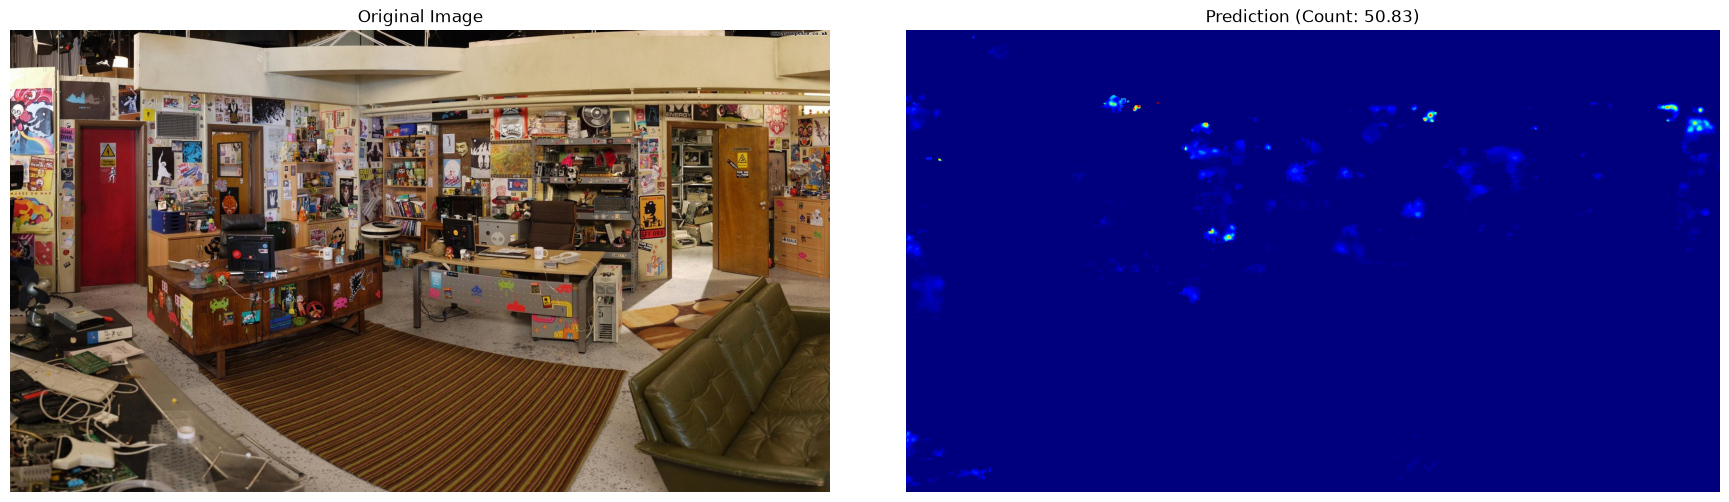

In [29]:
vis.visualize_sample(original_image, pred=result, cmap='jet')

In [11]:
vis.visualize_model_graph(model.model, sample=sample)

************
Feature extraction failed; returning model and environment to normal
*************
'Tensor' object has no attribute 'tl_tensor_label_raw'
